In [3]:
# Importing essential libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline   
# displays plot inside notebook

In [4]:
# Loading dataset with correct encoding (Windows CSV fix)

data = pd.read_csv(
    r"D:\Vinayak_IT_Internship\Month1\Task3\dataset\superstore.csv",
    encoding="latin1"
)


In [5]:
#Displaying first 5 rows of the dataset to understand structure and columns
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Checking dataset information such as:
# number of rows, columns, data types, and missing values

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Checking how many duplicate rows are present in the dataset

data.duplicated().sum()


np.int64(0)

In [8]:
# Removing duplicate rows to clean the dataset

data = data.drop_duplicates()


In [9]:
# Checking dataset shape (rows, columns) after removing duplicates

data.shape


(9994, 21)

In [10]:
# Generating statistical summary for numerical columns
# Includes mean, median, standard deviation, min, max, etc.

data.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Feature Creation (Lag, Rolling, Interaction)


In [11]:
# Convert to datetime (if not already)
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Create time-based features
data['day_of_week'] = data['Order Date'].dt.dayofweek
data['month'] = data['Order Date'].dt.month
data['quarter'] = data['Order Date'].dt.quarter
data['year'] = data['Order Date'].dt.year

# Check new columns
data[['Order Date','day_of_week','month','quarter','year']].head()


,Order Date,day_of_week,month,quarter,year
0,2016-11-08,1,11,4,2016
1,2016-11-08,1,11,4,2016
2,2016-06-12,6,6,2,2016
3,2015-10-11,6,10,4,2015
4,2015-10-11,6,10,4,2015


In [12]:
# Sort by date before creating lag features
data = data.sort_values('Order Date')

# Create lag features
data['sales_lag_1'] = data['Sales'].shift(1)
data['sales_lag_7'] = data['Sales'].shift(7)

# Check lag features
data[['Order Date','Sales','sales_lag_1','sales_lag_7']].head(10)


,Order Date,Sales,sales_lag_1,sales_lag_7
7980,2014-01-03,16.448,NaN,NaN
739,2014-01-04,11.784,16.448,NaN
740,2014-01-04,272.736,11.784,NaN
741,2014-01-04,3.540,272.736,NaN
1759,2014-01-05,19.536,3.540,NaN
7476,2014-01-06,5.480,19.536,NaN
7474,2014-01-06,2573.820,5.480,NaN
7475,2014-01-06,609.980,2573.820,16.448
7180,2014-01-06,12.780,609.980,11.784
7477,2014-01-06,391.980,12.780,272.736


In [13]:
# Create rolling statistics (7-day window)
data['rolling_mean_7'] = data['Sales'].rolling(window=7).mean()
data['rolling_std_7'] = data['Sales'].rolling(window=7).std()

# Check rolling features
data[['Order Date','Sales','rolling_mean_7','rolling_std_7']].head(15)


,Order Date,Sales,rolling_mean_7,rolling_std_7
7980,2014-01-03,16.448,NaN,NaN
739,2014-01-04,11.784,NaN,NaN
740,2014-01-04,272.736,NaN,NaN
741,2014-01-04,3.540,NaN,NaN
1759,2014-01-05,19.536,NaN,NaN
7476,2014-01-06,5.480,NaN,NaN
7474,2014-01-06,2573.820,414.763429,957.041189
7475,2014-01-06,609.980,499.553714,942.045258
7180,2014-01-06,12.780,499.696000,941.959378
7477,2014-01-06,391.980,516.730857,938.241743


In [14]:
# Create interaction features
data['sales_quantity'] = data['Sales'] * data['Quantity']
data['profit_margin'] = data['Profit'] / (data['Sales'] + 1)
data['discount_ratio'] = data['Discount'] / (data['Sales'] + 1)

# Check interaction features
data[['Sales','Quantity','Profit','Discount',
      'sales_quantity','profit_margin','discount_ratio']].head()


,Sales,Quantity,Profit,Discount,sales_quantity,profit_margin,discount_ratio
7980,16.448,2,5.5512,0.2,32.896,0.318157,0.011463
739,11.784,3,4.2717,0.2,35.352,0.334144,0.015645
740,272.736,3,-64.7748,0.2,818.208,-0.236632,0.000731
741,3.540,2,-5.4870,0.8,7.080,-1.208590,0.176211
1759,19.536,3,4.8840,0.2,58.608,0.237826,0.009739


In [15]:
# Check missing values after feature creation
data.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
day_of_week       0
month             0
quarter           0
year              0
sales_lag_1       1
sales_lag_7       7
rolling_mean_7    6
rolling_std_7     6
sales_quantity    0
profit_margin     0
discount_ratio    0
dtype: int64

In [16]:
# Remove rows with NaN values created by lag/rolling
data = data.dropna().reset_index(drop=True)

# Confirm cleaning
data.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
day_of_week       0
month             0
quarter           0
year              0
sales_lag_1       0
sales_lag_7       0
rolling_mean_7    0
rolling_std_7     0
sales_quantity    0
profit_margin     0
discount_ratio    0
dtype: int64

## Handling Categorical Variables (Encoding Techniques)
(One-Hot, Label, Target, Frequency Encoding)


In [17]:
# Identify categorical columns
cat_cols = data.select_dtypes(include=['object']).columns

cat_cols


Index(['Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name'],
      dtype='object')

In [18]:
# One-Hot Encoding
data_onehot = pd.get_dummies(
    data,
    columns=['Region', 'Category', 'Segment'],
    drop_first=True
)

# Check result
data_onehot.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Country,City,State,...,sales_quantity,profit_margin,discount_ratio,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology,Segment_Corporate,Segment_Home Office
0,7476,CA-2014-167199,2014-01-06,1/10/2014,Standard Class,ME-17320,Maria Etezadi,United States,Henderson,Kentucky,...,1219.96,0.449263,0.0,False,True,False,True,False,False,True
1,7181,CA-2014-106054,2014-01-06,1/7/2014,First Class,JO-15145,Jack O'Briant,United States,Athens,Georgia,...,38.34,0.380247,0.0,False,True,False,True,False,True,False
2,7478,CA-2014-167199,2014-01-06,1/10/2014,Standard Class,ME-17320,Maria Etezadi,United States,Henderson,Kentucky,...,783.96,0.289262,0.0,False,True,False,False,True,False,True
3,7479,CA-2014-167199,2014-01-06,1/10/2014,Standard Class,ME-17320,Maria Etezadi,United States,Henderson,Kentucky,...,3023.84,0.269643,0.0,False,True,False,False,True,False,True
4,7480,CA-2014-167199,2014-01-06,1/10/2014,Standard Class,ME-17320,Maria Etezadi,United States,Henderson,Kentucky,...,124.48,0.009689,0.0,False,True,False,True,False,False,True


In [19]:

#Label encoding
from sklearn.preprocessing import LabelEncoder

# Copy data to avoid overwriting
data_label = data.copy()

le = LabelEncoder()

# Apply to one column (example: Ship Mode)
data_label['Ship Mode'] = le.fit_transform(data_label['Ship Mode'])

# Check result
data_label[['Ship Mode']].head()


,Ship Mode
0,3
1,0
2,3
3,3
4,3


In [20]:
# Frequency Encoding for high-cardinality column
freq_map = data['Product ID'].value_counts()

data['product_freq'] = data['Product ID'].map(freq_map)

# Check result
data[['Product ID','product_freq']].head()


,Product ID,product_freq
0,OFF-BI-10004632,14
1,OFF-AR-10002399,7
2,TEC-PH-10004977,9
3,TEC-PH-10004539,7
4,OFF-FA-10001883,4


In [21]:
!pip install category_encoders


Defaulting to user installation because normal site-packages is not writeable


In [22]:
import category_encoders as ce

# Target Encoding (using Sales as target)
target_encoder = ce.TargetEncoder(cols=['Category'])

data_target = data.copy()

data_target['Category_enc'] = target_encoder.fit_transform(
    data_target['Category'],
    data_target['Sales']
)

# Check result
data_target[['Category','Category_enc']].head()


,Category,Category_enc
0,Office Supplies,119.388290
1,Office Supplies,119.388290
2,Technology,452.709276
3,Technology,452.709276
4,Office Supplies,119.388290


## Embedding-Based Encoding (Concept)

Embedding encoding is mainly used in deep learning models.
It converts categorical variables into dense vector representations.

In this project, embedding is not implemented practically,
but the concept is studied for future deep learning applications.

Example: Keras Embedding Layer.


In [23]:
!pip install tensorflow

from tensorflow.keras.layers import Embedding

# Example embedding layer (demonstration only)
embedding_layer = Embedding(input_dim=1000, output_dim=8)


Defaulting to user installation because normal site-packages is not writeable


## Encoding Summary

In this section, multiple encoding techniques were applied:

- One-Hot Encoding for low-cardinality features
- Label Encoding for ordinal features
- Frequency Encoding for high-cardinality features
- Target Encoding for predictive relationship
- Embedding Encoding (conceptual)

These techniques help convert categorical data into numerical format
for machine learning models.


## Feature Selection Techniques
(Correlation, Mutual Information, RFE, Tree-Based Importance)



In [24]:
# Select target variable
y = data['Sales']

# Select numerical features only
X = data.drop(['Sales'], axis=1)

# Keep only numeric columns
X = X.select_dtypes(include=['int64','float64'])

# Handle missing values
X = X.fillna(0)

X.shape, y.shape


((9987, 13), (9987,))

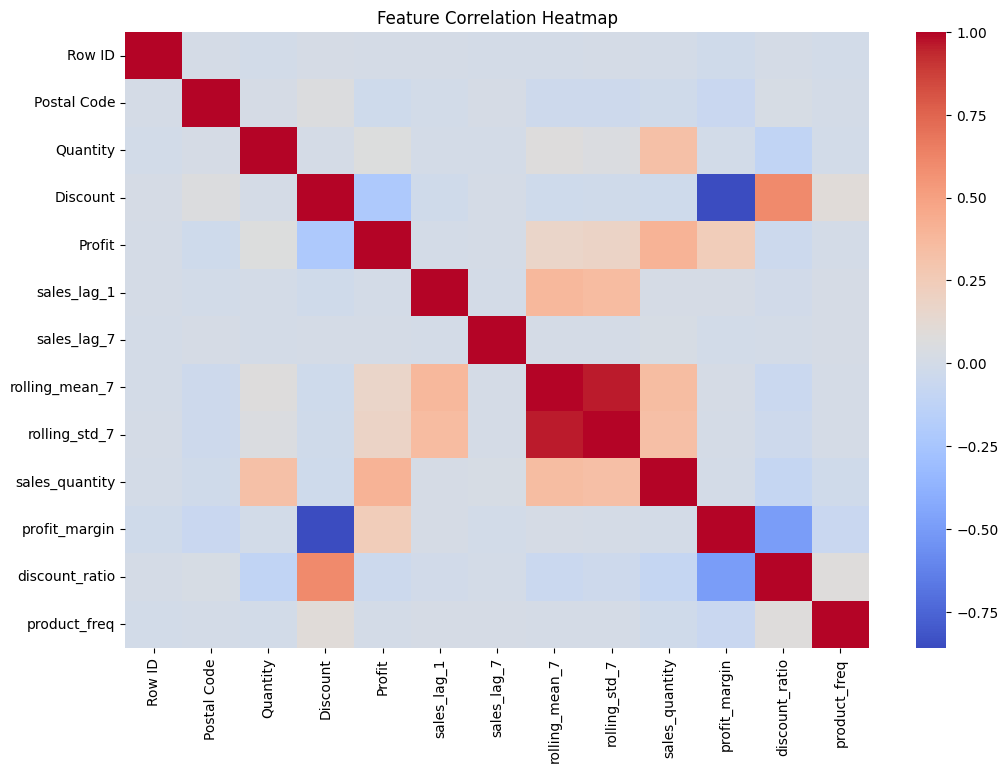

In [25]:
# Correlation-Based Selection
#  Correlation matrix
plt.figure(figsize=(12,8))
corr_matrix = X.corr()

sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [26]:
# Remove Highly Correlated Features
# Identify highly correlated features (>0.9)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns 
    if any(upper[column] > 0.9)
]

high_corr


['rolling_std_7']

In [27]:
#Mutual Information Selection
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

mi_series.head(15)


sales_quantity    4.527927
discount_ratio    2.156622
Profit            1.969143
profit_margin     1.607501
Quantity          0.454446
Discount          0.299183
rolling_std_7     0.297622
product_freq      0.185480
rolling_mean_7    0.125808
Postal Code       0.032320
sales_lag_1       0.016035
Row ID            0.001650
sales_lag_7       0.000000
dtype: float64

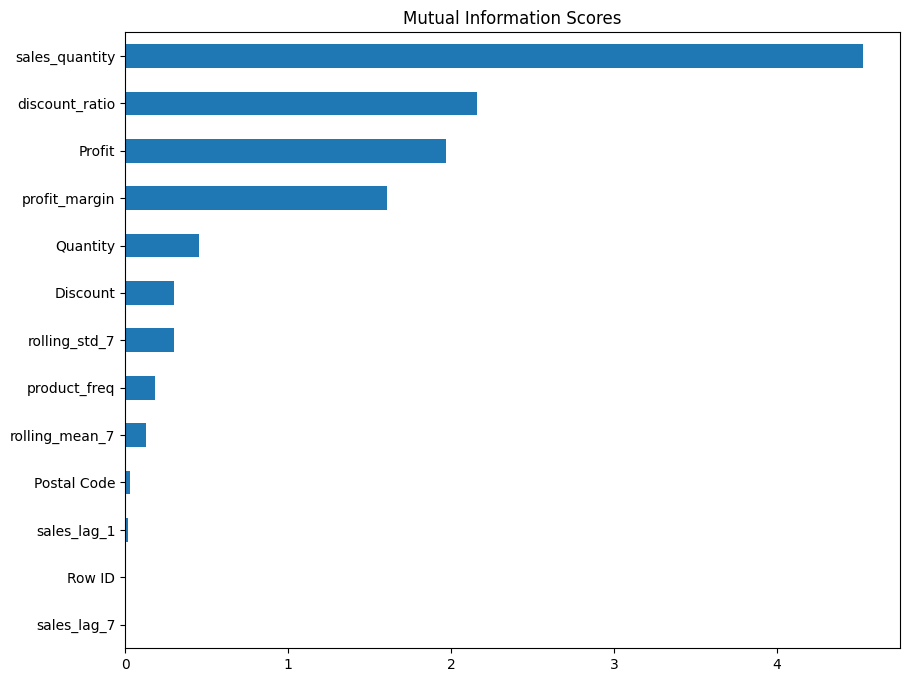

In [28]:
mi_series.sort_values().plot(kind='barh', figsize=(10,8))
plt.title("Mutual Information Scores")
plt.show()


In [29]:
#Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

rfe = RFE(model, n_features_to_select=10)

rfe.fit(X, y)

selected_features = X.columns[rfe.support_]

selected_features



Index(['Quantity', 'Discount', 'Profit', 'sales_lag_1', 'rolling_mean_7',
       'rolling_std_7', 'sales_quantity', 'profit_margin', 'discount_ratio',
       'product_freq'],
      dtype='object')

In [30]:
#tree based feature importance
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X, y)

importances = rf_model.feature_importances_

imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

imp_series.head(15)


sales_quantity    0.706216
rolling_std_7     0.194561
rolling_mean_7    0.032630
Profit            0.026259
Quantity          0.025511
sales_lag_7       0.003133
product_freq      0.002820
sales_lag_1       0.001844
discount_ratio    0.001727
Postal Code       0.001497
Discount          0.001474
profit_margin     0.001169
Row ID            0.001158
dtype: float64

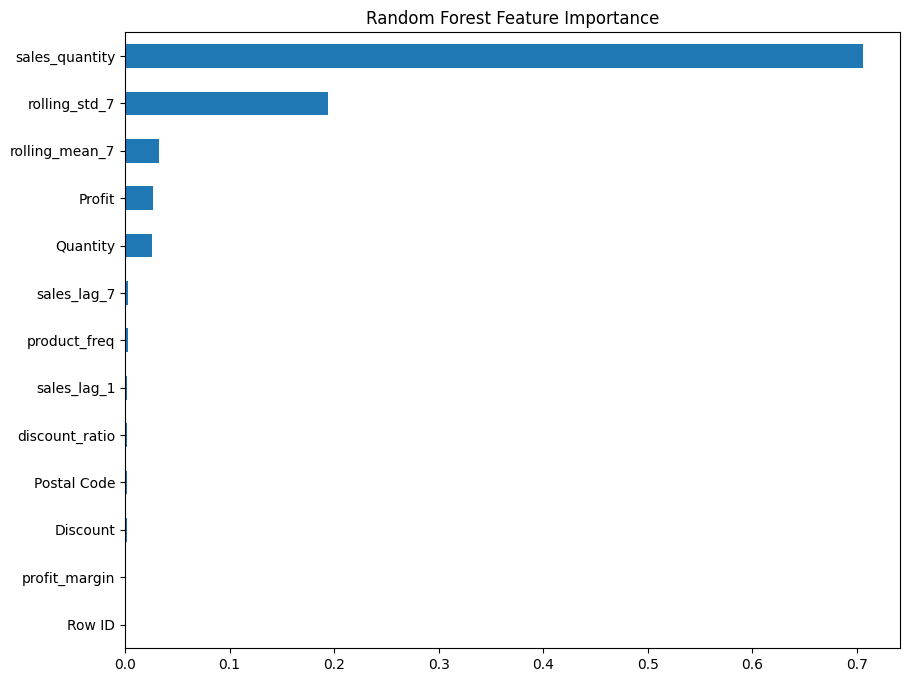

In [31]:
imp_series.sort_values().plot(kind='barh', figsize=(10,8))
plt.title("Random Forest Feature Importance")
plt.show()


## Feature Selection Summary

In this section, multiple feature selection techniques were applied:

- Correlation analysis to detect multicollinearity
- Mutual Information to measure dependency with target
- Recursive Feature Elimination (RFE) to select optimal features
- Random Forest importance for tree-based ranking

Important features were identified for model training.


## Data Transformation and Preprocessing Pipeline
(Skewness Handling, Scaling, Normalization, Pipeline, Validation)


In [32]:
# Check skewness of numerical columns
data.skew(numeric_only=True)


Row ID             0.000029
Postal Code       -0.128621
Sales             12.992315
Quantity           1.278138
Discount           1.684283
Profit             7.567459
day_of_week       -0.276556
month             -0.429587
quarter           -0.463552
year              -0.284121
sales_lag_1       12.969021
sales_lag_7       12.968805
rolling_mean_7     4.934281
rolling_std_7      6.740753
sales_quantity    13.675514
profit_margin     -2.860512
discount_ratio     6.365438
product_freq       0.752351
dtype: float64

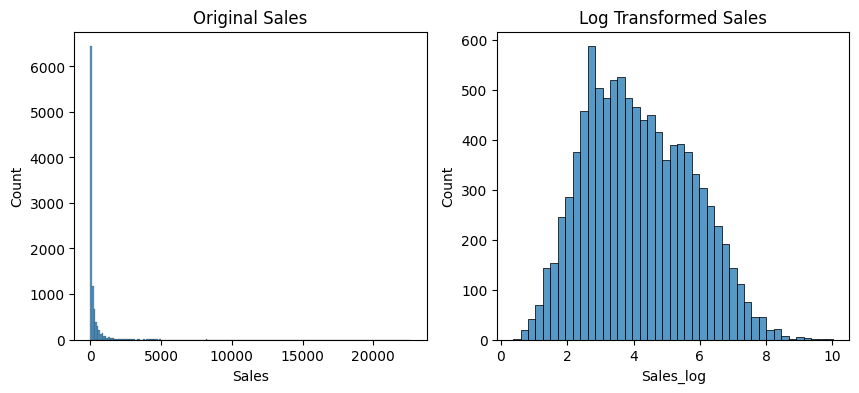

In [33]:
# Log transform Sales to reduce skewness
data['Sales_log'] = np.log1p(data['Sales'])

# Compare original vs log
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data['Sales'])
plt.title("Original Sales")

plt.subplot(1,2,2)
sns.histplot(data['Sales_log'])
plt.title("Log Transformed Sales")

plt.show()


In [34]:
# Target
y = data['Sales_log']

# Features
X = data.drop(['Sales','Sales_log'], axis=1)

# Keep numeric columns only
X = X.select_dtypes(include=['int64','float64'])

X.shape, y.shape


((9987, 13), (9987,))

In [35]:
#Min-Max Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


,Row ID,Postal Code,Quantity,Discount,Profit,sales_lag_1,sales_lag_7,rolling_mean_7,rolling_std_7,sales_quantity,profit_margin,discount_ratio,product_freq
0,0.858957,-0.398278,-0.804449,-0.756551,1.049807,3.759737,-0.342467,1.140966,1.145995,0.018511,0.771884,-0.293366,2.595434
1,0.756687,-0.766692,-0.354993,-0.756551,-0.099770,0.609591,-0.349949,1.141568,1.145827,-0.284972,0.609047,-0.293366,0.111156
2,0.859650,-0.398278,-0.804449,-0.756551,0.363194,-0.348363,0.068635,1.213652,1.138552,-0.093469,0.394379,-0.293366,0.820950
3,0.859997,-0.398278,0.094464,-0.756551,0.749309,0.259902,-0.363173,1.668494,1.087969,0.481814,0.348090,-0.293366,0.111156
4,0.860343,-0.398278,0.094464,-0.756551,-0.120813,0.843753,-0.337514,1.675496,1.085484,-0.262848,-0.265243,-0.293366,-0.953534


In [36]:
#Build Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor


In [37]:
# Identify columns
num_cols = X.columns
cat_cols = data.select_dtypes(include=['object']).columns


In [38]:
# Preprocessing pipelines
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [39]:
# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


In [40]:
# Full pipeline
full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])


In [41]:
# Train pipeline
full_pipeline.fit(data, data['Sales'])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [42]:
# Transform data
X_transformed = preprocessor.fit_transform(data)

# Check shape
X_transformed.shape


(9987, 12263)

In [47]:
# Check for NaN (on dense array, not sparse)
np.isnan(X_dense).sum()


np.int64(0)

In [46]:
data = data.fillna(0)

X_transformed = preprocessor.fit_transform(data)

X_dense = X_transformed.toarray()

np.isnan(X_dense).sum()


np.int64(0)